# Employee Attrition Analysis

**Final Project — Coach Academy Data Analytics Bootcamp**

This notebook takes the raw HR CSV from messy data to decision-ready outputs. The code is intentionally kept simple and each major step is explained before it is run.

The project answers four HR questions:

1. Is pay reasonably aligned with employee profiles?
2. Who is at higher predicted risk of leaving?
3. Who may be a high performer based only on background attributes?
4. What natural employee segments exist?

The notebook also exports the final dataset used by the Power BI dashboard.

## 1. Import Libraries

We use **pandas/numpy** for data work, **matplotlib** for charts, and **scikit-learn** for KNN, LOF, regression, SVM and K-Means.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, mean_absolute_error,
    mean_squared_error, precision_score, r2_score, recall_score,
    roc_auc_score, roc_curve, silhouette_score
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

ROOT = Path(".")
DATA_PATH = ROOT / "employee_attrition_raw.csv"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
RANDOM_STATE = 42

## 2. Load and Explore Raw Data

Before cleaning, we inspect the CSV itself. This helps us notice inconsistent categories, hidden missing values, duplicates and suspicious numeric values instead of assuming what is wrong.

In [2]:
raw = pd.read_csv(DATA_PATH)

print("Shape:", raw.shape)
display(raw.head())
print("\nData types:")
print(raw.dtypes)
print("\nMissing cells:")
print(raw.isna().sum())
print("\nExact duplicate rows:", raw.duplicated().sum())
print("Unique Employee IDs:", raw["Employee_ID"].nunique())

display(raw.describe(include="all").T)

Shape: (1045, 10)


,Employee_ID,Department,Job_Role,Education_Level,Age,Years_At_Company,Monthly_Income,Performance_Score,Join_Date,Attrition
0,601,Engineering,Software Engineer,Bachelor,21,13,7155.17,92.0,2011-07-15,No
1,737,SALES,Sales Executive,master,30,2,5122.52,59.0,2022-09-22,No
2,315,Finance,Accountant,Bachelor's,37,0,4578.13,80.0,2024-06-18,No
3,816,SALES,Sales Manager,Bachelor,31,0,3649.32,NaN,2024-08-15,No
4,979,marketing,Marketing Analyst,Bachelor,42,2,4218.21,75.0,2022-09-07,No



Data types:
Employee_ID            int64
Department               str
Job_Role                 str
Education_Level          str
Age                    int64
Years_At_Company         str
Monthly_Income           str
Performance_Score    float64
Join_Date                str
Attrition                str
dtype: object

Missing cells:
Employee_ID           0
Department            0
Job_Role              0
Education_Level       0
Age                   0
Years_At_Company     32
Monthly_Income       50
Performance_Score    43
Join_Date             0
Attrition             0
dtype: int64

Exact duplicate rows: 29
Unique Employee IDs: 1000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,1045.0,NaN,NaN,NaN,501.072727,288.758753,1.0,253.0,501.0,750.0,1000.0
Department,1045,22,Engineering,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Role,1045,15,Account Rep,109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,1045,12,Bachelor,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1045.0,NaN,NaN,NaN,34.488995,10.376399,4.0,29.0,34.0,39.0,130.0
Years_At_Company,1013,26,0,231,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Income,995,930,-999,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Performance_Score,1002.0,NaN,NaN,NaN,71.288423,12.102858,31.0,63.0,71.5,80.0,100.0
Join_Date,1045,822,2024-08-09,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Attrition,1045,2,No,883,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.1 Inspect Categorical Values

The raw file contains several text versions of the same department and education level. For example, Engineering appears with different capitalization/spelling, and Bachelor/Master/PhD also appear in multiple forms.

In [3]:
for column in ["Department", "Education_Level", "Attrition"]:
    print(f"\n{column}")
    print(raw[column].value_counts(dropna=False))


Department
Department
Engineering        182
Sales              167
Marketing          100
Finance             79
HR                  72
SALES               50
sales               49
engineering         46
Engineeering        42
FINANCE             36
Sales               29
finance             28
Human Resources     28
Eng.                28
MARKETING           25
marketing           21
Marketing           18
hr                  16
Finance             15
H.R.                 7
ENGINEERING          6
ENGINEEERING         1
Name: count, dtype: int64

Education_Level
Education_Level
Bachelor       347
Master         192
High School    123
bachelor        96
Bachelor's      72
PhD             51
Master's        46
master          41
high school     28
HS              22
Ph.D.           15
phd             12
Name: count, dtype: int64

Attrition
Attrition
No     883
Yes    162
Name: count, dtype: int64


## 3. Data Cleaning

### 3.1 Standardize Text

We remove extra spaces and map different spellings/capitalizations to one consistent value. We do **not** change the actual meaning of the categories.

In [4]:
df = raw.copy()

department_map = {
    "sales": "Sales",
    "engineering": "Engineering",
    "engineeering": "Engineering",
    "eng.": "Engineering",
    "finance": "Finance",
    "hr": "HR",
    "h.r.": "HR",
    "human resources": "HR",
    "marketing": "Marketing",
}

education_map = {
    "high school": "High School",
    "hs": "High School",
    "bachelor": "Bachelor",
    "bachelor's": "Bachelor",
    "master": "Master",
    "master's": "Master",
    "phd": "PhD",
    "ph.d.": "PhD",
}

df["Department"] = df["Department"].astype(str).str.strip().str.lower().replace(department_map)
df["Education_Level"] = df["Education_Level"].astype(str).str.strip().str.lower().replace(education_map)
df["Job_Role"] = df["Job_Role"].astype(str).str.strip()
df["Attrition"] = df["Attrition"].astype(str).str.strip().str.title()
df["Join_Date"] = pd.to_datetime(df["Join_Date"], errors="coerce")

print("Departments after cleaning:", sorted(df["Department"].unique()))
print("Education levels after cleaning:", sorted(df["Education_Level"].unique()))

Departments after cleaning: ['Engineering', 'Finance', 'HR', 'Marketing', 'Sales']
Education levels after cleaning: ['Bachelor', 'High School', 'Master', 'PhD']


### 3.2 Duplicate Detection

There are 1,045 raw rows but only 1,000 unique employees. After text is standardized, all repeated employee records become exact duplicates. We remove one copy of each duplicate and verify that no duplicate Employee_ID remains.

In [5]:
print("Duplicates after text standardization:", df.duplicated().sum())

df = df.drop_duplicates().copy().reset_index(drop=True)

print("Rows after duplicate removal:", len(df))
print("Duplicate Employee_ID values remaining:", df["Employee_ID"].duplicated().sum())

Duplicates after text standardization: 45
Rows after duplicate removal: 1000
Duplicate Employee_ID values remaining: 0


### 3.3 Hidden Missing Values

Missing values are not only blank cells. In this file, numeric columns also contain `?` and `-999`, which are not realistic values and are used as placeholders. We convert them to real `NaN` values before imputation.

In [6]:
placeholder_rows = []
for column in ["Years_At_Company", "Monthly_Income"]:
    text_values = df[column].astype(str).str.strip()
    placeholder_rows.append({
        "Column": column,
        "Blank/NaN": df[column].isna().sum(),
        "?": (text_values == "?").sum(),
        "-999": (text_values == "-999").sum(),
    })

placeholder_table = pd.DataFrame(placeholder_rows)
display(placeholder_table)

df["Years_At_Company"] = pd.to_numeric(
    df["Years_At_Company"].replace({"?": np.nan, "-999": np.nan}), errors="coerce"
)
df["Monthly_Income"] = pd.to_numeric(
    df["Monthly_Income"].replace({"?": np.nan, "-999": np.nan}), errors="coerce"
)
df["Performance_Score"] = pd.to_numeric(df["Performance_Score"], errors="coerce")

numeric_for_imputation = ["Age", "Years_At_Company", "Monthly_Income", "Performance_Score"]
print("Missing numeric values before KNN:")
print(df[numeric_for_imputation].isna().sum())

,Column,Blank/NaN,?,-999
0,Years_At_Company,32,12,11
1,Monthly_Income,48,9,13


Missing numeric values before KNN:
Age                   0
Years_At_Company     55
Monthly_Income       70
Performance_Score    40
dtype: int64


### 3.4 KNN Imputation

The assignment requires **K-Nearest Neighbors (KNN) imputation**. We use `k=5` and the `nan_euclidean` distance metric.

Because KNN is distance-based, the numeric fields are standardized first. Otherwise, Monthly Income would dominate the distance calculation simply because it has larger numbers than Age or Tenure.

In [7]:
imputation_scaler = StandardScaler()
scaled_with_missing = imputation_scaler.fit_transform(df[numeric_for_imputation])

knn_imputer = KNNImputer(
    n_neighbors=5,
    weights="uniform",
    metric="nan_euclidean"
)

imputed_scaled = knn_imputer.fit_transform(scaled_with_missing)
df[numeric_for_imputation] = imputation_scaler.inverse_transform(imputed_scaled)

print("Missing numeric values after KNN:")
print(df[numeric_for_imputation].isna().sum())

Missing numeric values after KNN:
Age                  0
Years_At_Company     0
Monthly_Income       0
Performance_Score    0
dtype: int64


### 3.5 LOF Outlier Detection and Removal

The assignment requires **Local Outlier Factor (LOF)**. LOF compares each employee with nearby employees and flags records that have unusually low local density.

We use the numeric employee profile fields, standardize them, set `n_neighbors=20`, and use `contamination='auto'` so we do not guess an exact outlier percentage.

In [8]:
pre_lof = df.copy()
lof_features = ["Age", "Years_At_Company", "Monthly_Income", "Performance_Score"]

lof_scaler = StandardScaler()
lof_input = lof_scaler.fit_transform(pre_lof[lof_features])

lof = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_labels = lof.fit_predict(lof_input)

pre_lof["LOF_Flag"] = np.where(lof_labels == -1, "Outlier", "Inlier")
pre_lof["LOF_Score"] = lof.negative_outlier_factor_

outliers = pre_lof[pre_lof["LOF_Flag"] == "Outlier"].copy().sort_values("LOF_Score")
clean = pre_lof[pre_lof["LOF_Flag"] == "Inlier"].drop(columns=["LOF_Flag", "LOF_Score"]).copy().reset_index(drop=True)

print("LOF outliers found:", len(outliers))
print("Rows remaining:", len(clean))
display(outliers[["Employee_ID", "Age", "Years_At_Company", "Monthly_Income", "Performance_Score", "LOF_Score"]].head(15))

outliers.to_csv(ROOT / "lof_flagged_outliers.csv", index=False)

LOF outliers found: 40
Rows remaining: 960


,Employee_ID,Age,Years_At_Company,Monthly_Income,Performance_Score,LOF_Score
67,223,130.0,0.0,2784.64,80.0,-7.263813
88,26,130.0,1.0,3541.41,77.0,-7.208875
801,853,130.0,0.0,6464.11,64.0,-7.069249
566,57,130.0,3.0,5674.04,47.0,-6.623898
504,486,130.0,3.0,3471.58,66.0,-6.561116
552,670,28.0,0.0,30291.57,76.0,-4.679873
261,700,32.0,0.0,23594.67,69.0,-4.441197
511,118,26.0,2.0,29220.75,65.0,-4.260579
446,865,37.0,4.0,37099.71,74.2,-3.335002
923,48,38.0,7.0,77172.12,72.6,-3.216202


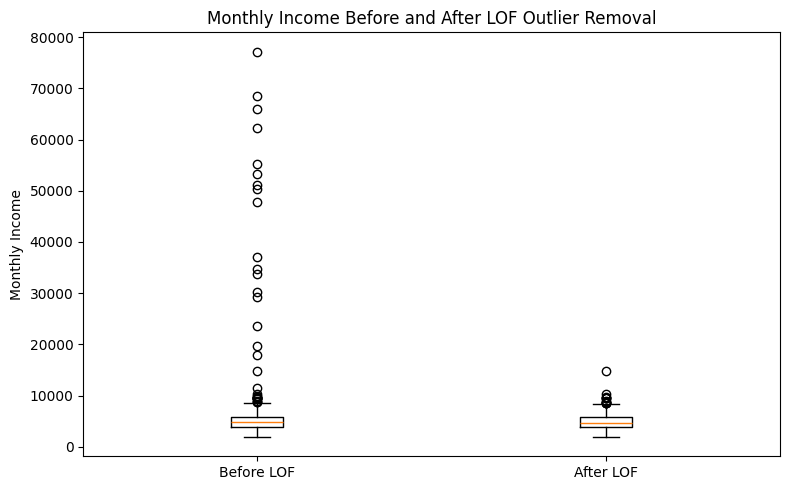

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [pre_lof["Monthly_Income"], clean["Monthly_Income"]],
    tick_labels=["Before LOF", "After LOF"]
)
ax.set_title("Monthly Income Before and After LOF Outlier Removal")
ax.set_ylabel("Monthly Income")
plt.tight_layout()
plt.savefig(FIGURES / "lof_before_after.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Encoding, Class Imbalance and Scaling

- **Education Level is ordinal** because High School < Bachelor < Master < PhD.
- **Department and Job Role are nominal** because there is no natural ranking, so we use one-hot encoding.
- **Attrition is imbalanced**, so Logistic Regression uses `class_weight='balanced'`.
- Numeric features are standardized inside model pipelines whenever feature scale matters.

Using pipelines also ensures that preprocessing is fitted on the training data during model evaluation.

Attrition
No     806
Yes    154
Name: count, dtype: int64
Attrition rate: 16.04%


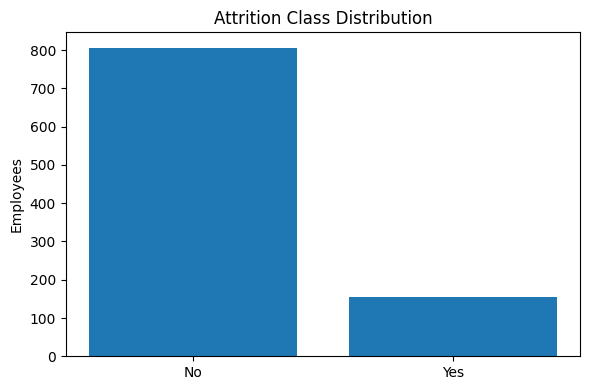

In [10]:
print(clean["Attrition"].value_counts())
print("Attrition rate:", f"{(clean['Attrition'] == 'Yes').mean():.2%}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = clean["Attrition"].value_counts().reindex(["No", "Yes"])
ax.bar(counts.index, counts.values)
ax.set_title("Attrition Class Distribution")
ax.set_ylabel("Employees")
plt.tight_layout()
plt.savefig(FIGURES / "attrition_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

### Helper: Reusable Preprocessing Pipeline

This small helper keeps the models readable. Numeric fields are scaled, Education is ordinal encoded, and Department/Job Role are one-hot encoded.

In [11]:
def make_preprocessor(numeric_columns, nominal_columns):
    education_order = [["High School", "Bachelor", "Master", "PhD"]]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_columns),
            ("edu", OrdinalEncoder(
                categories=education_order,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ), ["Education_Level"]),
            ("cat", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ), nominal_columns),
        ],
        verbose_feature_names_out=False,
    )

## 5. Pay Equity Analysis — Linear Regression

### 5.1 Goal

Predict expected Monthly Income from employee profile information, then compare actual income with predicted income. Monthly Income is **not** used as an input feature because it is the target.

In [12]:
pay_features = [
    "Age", "Years_At_Company", "Education_Level",
    "Department", "Job_Role", "Performance_Score"
]
X_pay = clean[pay_features]
y_pay = clean["Monthly_Income"]

X_pay_train, X_pay_test, y_pay_train, y_pay_test = train_test_split(
    X_pay, y_pay, test_size=0.20, random_state=RANDOM_STATE
)

pay_model = Pipeline([
    ("preprocess", make_preprocessor(
        ["Age", "Years_At_Company", "Performance_Score"],
        ["Department", "Job_Role"]
    )),
    ("model", LinearRegression())
])

pay_model.fit(X_pay_train, y_pay_train)
pay_test_pred = pay_model.predict(X_pay_test)

pay_r2 = r2_score(y_pay_test, pay_test_pred)
pay_mae = mean_absolute_error(y_pay_test, pay_test_pred)
pay_rmse = mean_squared_error(y_pay_test, pay_test_pred) ** 0.5

print(f"R²:   {pay_r2:.3f}")
print(f"MAE:  {pay_mae:.2f}")
print(f"RMSE: {pay_rmse:.2f}")

R²:   0.636
MAE:  632.41
RMSE: 830.43


The pay model is reasonably useful as a screening model, but it should not be treated as proof of unfair compensation. The test R² is about **0.64**, meaning the model explains a meaningful part of salary variation but not all of it.

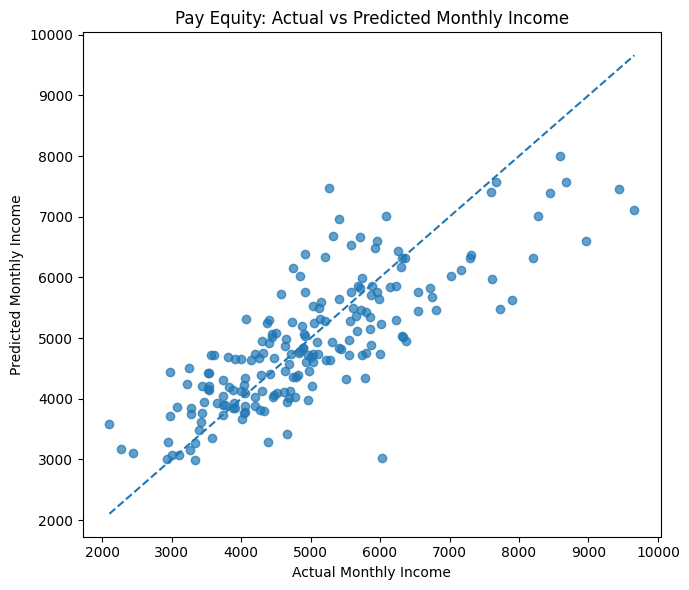

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_pay_test, pay_test_pred, alpha=0.7)
low = min(y_pay_test.min(), pay_test_pred.min())
high = max(y_pay_test.max(), pay_test_pred.max())
ax.plot([low, high], [low, high], linestyle="--")
ax.set_title("Pay Equity: Actual vs Predicted Monthly Income")
ax.set_xlabel("Actual Monthly Income")
ax.set_ylabel("Predicted Monthly Income")
plt.tight_layout()
plt.savefig(FIGURES / "pay_equity_actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

### 5.2 Pay-Equity Review Flags

After evaluating the model, we fit it to all cleaned rows to create expected income estimates. Employees whose residual is more than **2 standard deviations** from expected are flagged for review.

The labels are neutral: **Below Expected**, **Above Expected**, or **Within Expected Range**. These are analytical screening flags, not legal conclusions.

In [14]:
pay_model.fit(X_pay, y_pay)
clean["Predicted_Income"] = pay_model.predict(X_pay)
clean["Pay_Gap"] = clean["Monthly_Income"] - clean["Predicted_Income"]
clean["Pay_Gap_Percent"] = 100 * clean["Pay_Gap"] / clean["Predicted_Income"]

residual_sd = clean["Pay_Gap"].std(ddof=1)
clean["Pay_Equity_Flag"] = np.select(
    [clean["Pay_Gap"] < -2 * residual_sd,
     clean["Pay_Gap"] >  2 * residual_sd],
    ["Below Expected", "Above Expected"],
    default="Within Expected Range"
)

pay_flags = clean[clean["Pay_Equity_Flag"] != "Within Expected Range"].copy()
print(clean["Pay_Equity_Flag"].value_counts())
display(pay_flags[[
    "Employee_ID", "Department", "Job_Role", "Monthly_Income",
    "Predicted_Income", "Pay_Gap", "Pay_Gap_Percent", "Pay_Equity_Flag"
]].sort_values("Pay_Gap").head(10))

Pay_Equity_Flag
Within Expected Range    921
Below Expected            20
Above Expected            19
Name: count, dtype: int64


,Employee_ID,Department,Job_Role,Monthly_Income,Predicted_Income,Pay_Gap,Pay_Gap_Percent,Pay_Equity_Flag
305,143,Engineering,QA Engineer,4609.488,9506.700807,-4897.212807,-51.513274,Below Expected
516,726,Sales,Account Rep,4041.110,6665.698114,-2624.588114,-39.374542,Below Expected
90,899,Sales,Sales Executive,2901.760,5488.776289,-2587.016289,-47.132843,Below Expected
707,69,HR,HR Manager,4917.250,7486.216620,-2568.966620,-34.315954,Below Expected
545,94,Sales,Sales Executive,5262.232,7562.749448,-2300.517448,-30.419062,Below Expected
541,91,Engineering,Software Engineer,4533.898,6830.275649,-2296.377649,-33.620571,Below Expected
511,11,Finance,Accountant,4620.052,6871.272462,-2251.220462,-32.762788,Below Expected
230,512,Engineering,Software Engineer,3989.546,6212.019014,-2222.473014,-35.776983,Below Expected
816,600,Finance,Accountant,3673.120,5889.565491,-2216.445491,-37.633430,Below Expected
471,809,HR,HR Specialist,2617.540,4741.220800,-2123.680800,-44.791856,Below Expected


## 6. Attrition Prediction — Logistic Regression

We predict whether an employee leaves (`Attrition`). Because the Yes class is much smaller than the No class, the model uses `class_weight='balanced'` and a stratified train/test split.

In [15]:
attrition_features = [
    "Age", "Years_At_Company", "Monthly_Income", "Performance_Score",
    "Education_Level", "Department", "Job_Role"
]
X_attr = clean[attrition_features]
y_attr = (clean["Attrition"] == "Yes").astype(int)

X_attr_train, X_attr_test, y_attr_train, y_attr_test = train_test_split(
    X_attr, y_attr, test_size=0.20, random_state=RANDOM_STATE, stratify=y_attr
)

attrition_model = Pipeline([
    ("preprocess", make_preprocessor(
        ["Age", "Years_At_Company", "Monthly_Income", "Performance_Score"],
        ["Department", "Job_Role"]
    )),
    ("model", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    ))
])

attrition_model.fit(X_attr_train, y_attr_train)
attr_pred = attrition_model.predict(X_attr_test)
attr_prob = attrition_model.predict_proba(X_attr_test)[:, 1]

attr_accuracy = accuracy_score(y_attr_test, attr_pred)
attr_precision = precision_score(y_attr_test, attr_pred)
attr_recall = recall_score(y_attr_test, attr_pred)
attr_f1 = f1_score(y_attr_test, attr_pred)
attr_auc = roc_auc_score(y_attr_test, attr_prob)

print(f"Accuracy:  {attr_accuracy:.3f}")
print(f"Precision: {attr_precision:.3f}")
print(f"Recall:    {attr_recall:.3f}")
print(f"F1:        {attr_f1:.3f}")
print(f"ROC-AUC:   {attr_auc:.3f}")

Accuracy:  0.599
Precision: 0.220
Recall:    0.581
F1:        0.319
ROC-AUC:   0.571


The attrition model is **weak/modest**, with ROC-AUC around **0.57**. It should be used only as a rough risk-screening tool. Recall is more informative than accuracy here because missing a real leaver (a false negative) is important for HR.

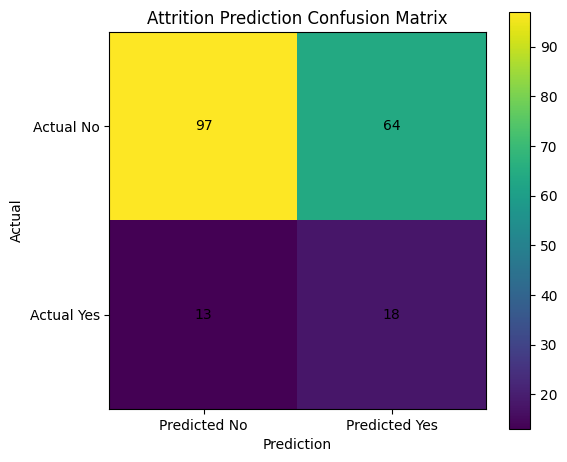

In [16]:
attr_cm = confusion_matrix(y_attr_test, attr_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attr_cm)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(attr_cm[i, j]), ha="center", va="center")
ax.set_xticks([0, 1], labels=["Predicted No", "Predicted Yes"])
ax.set_yticks([0, 1], labels=["Actual No", "Actual Yes"])
ax.set_title("Attrition Prediction Confusion Matrix")
ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "attrition_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

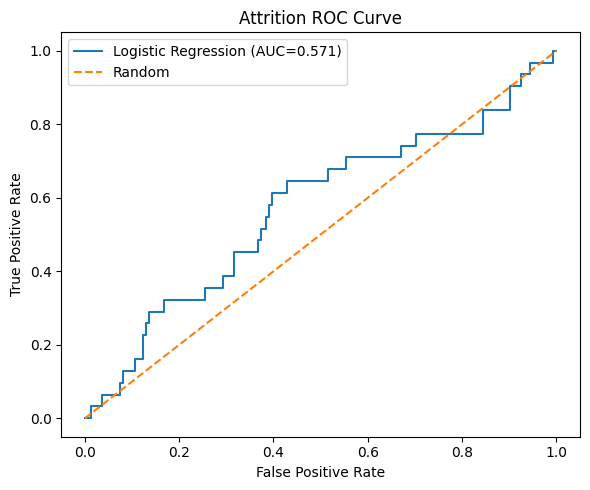

In [17]:
fpr, tpr, _ = roc_curve(y_attr_test, attr_prob)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC={attr_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random")
ax.set_title("Attrition ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "attrition_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

### 6.1 Which Factors Matter Most?

For Logistic Regression, coefficient size shows which transformed features have the strongest association with the model prediction. Positive coefficients increase predicted attrition probability; negative coefficients decrease it. This is association, **not causation**.

,Feature,Coefficient,Absolute_Coefficient
19,Job_Role_QA Engineer,-0.727780,0.727780
23,Job_Role_Senior Engineer,0.640752,0.640752
12,Job_Role_Content Specialist,-0.509718,0.509718
2,Monthly_Income,-0.436696,0.436696
10,Job_Role_Account Rep,-0.413039,0.413039
4,Education_Level,0.412715,0.412715
17,Job_Role_Marketing Analyst,0.263900,0.263900
0,Age,0.241506,0.241506
16,Job_Role_HR Specialist,-0.241219,0.241219
18,Job_Role_Marketing Manager,0.231298,0.231298


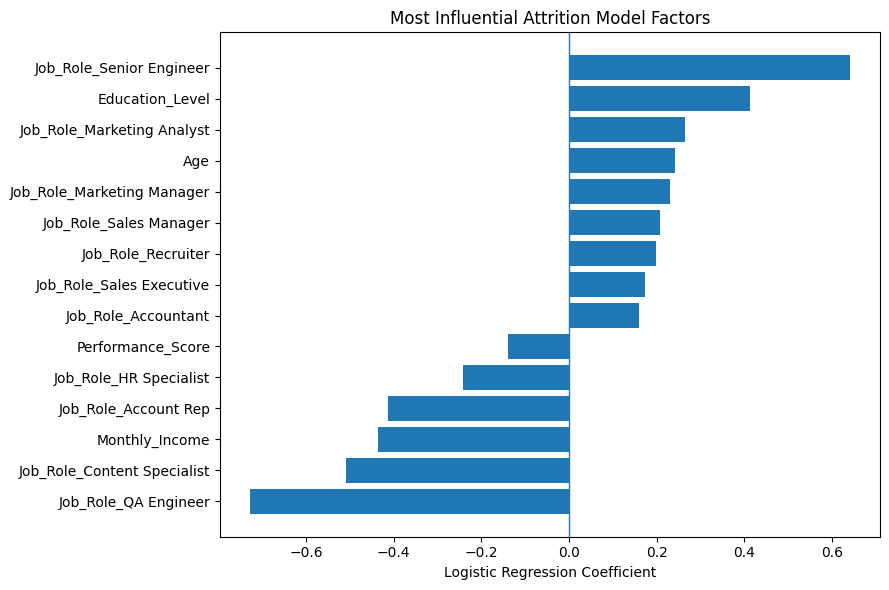

In [18]:
feature_names = attrition_model.named_steps["preprocess"].get_feature_names_out()
coefficients = attrition_model.named_steps["model"].coef_[0]
attr_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values("Absolute_Coefficient", ascending=False)

display(attr_importance.head(12))

top_attr = attr_importance.head(15).sort_values("Coefficient")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_attr["Feature"], top_attr["Coefficient"])
ax.axvline(0, linewidth=1)
ax.set_title("Most Influential Attrition Model Factors")
ax.set_xlabel("Logistic Regression Coefficient")
plt.tight_layout()
plt.savefig(FIGURES / "attrition_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

In [19]:
# Final risk probabilities for the Power BI reporting dataset.
attrition_model.fit(X_attr, y_attr)
clean["Attrition_Risk_Probability"] = attrition_model.predict_proba(X_attr)[:, 1]
clean["Attrition_Risk_Level"] = pd.cut(
    clean["Attrition_Risk_Probability"],
    bins=[-np.inf, 0.35, 0.65, np.inf],
    labels=["Low", "Medium", "High"]
).astype(str)

print(clean["Attrition_Risk_Level"].value_counts())

Attrition_Risk_Level
Medium    696
Low       179
High       85
Name: count, dtype: int64


## 7. Talent Identification — SVM

A **High Performer** is defined by the assignment as `Performance_Score >= 85`.

### Critical leakage rule

`Performance_Score` is **not** used as a predictor in this model. Using the score that directly defines the target would make the model meaningless. We use only background attributes.

We compare a **Linear SVM** with an **RBF SVM** using the same train/test split.

In [20]:
clean["High_Performer"] = (clean["Performance_Score"] >= 85).astype(int)

talent_features = [
    "Age", "Years_At_Company", "Monthly_Income",
    "Education_Level", "Department", "Job_Role"
]
X_talent = clean[talent_features]
y_talent = clean["High_Performer"]

print("High performer distribution:")
print(y_talent.value_counts())

X_talent_train, X_talent_test, y_talent_train, y_talent_test = train_test_split(
    X_talent, y_talent, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_talent
)

talent_preprocessor = make_preprocessor(
    ["Age", "Years_At_Company", "Monthly_Income"],
    ["Department", "Job_Role"]
)

results = []
models = {}
for kernel in ["linear", "rbf"]:
    svm = Pipeline([
        ("preprocess", talent_preprocessor),
        ("model", SVC(
            kernel=kernel,
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])
    svm.fit(X_talent_train, y_talent_train)
    pred = svm.predict(X_talent_test)
    prob = svm.predict_proba(X_talent_test)[:, 1]

    results.append({
        "Model": f"SVM - {kernel.title()} Kernel",
        "Kernel": kernel,
        "Accuracy": accuracy_score(y_talent_test, pred),
        "Precision": precision_score(y_talent_test, pred),
        "Recall": recall_score(y_talent_test, pred),
        "F1": f1_score(y_talent_test, pred),
        "ROC_AUC": roc_auc_score(y_talent_test, prob),
    })
    models[kernel] = svm

svm_comparison = pd.DataFrame(results)
display(svm_comparison)

High performer distribution:
High_Performer
0    834
1    126
Name: count, dtype: int64


,Model,Kernel,Accuracy,Precision,Recall,F1,ROC_AUC
0,SVM - Linear Kernel,linear,0.557292,0.142857,0.48,0.220183,0.542754
1,SVM - Rbf Kernel,rbf,0.505208,0.093023,0.32,0.144144,0.541796


The **Linear SVM** is selected because it gives the better F1 score on this dataset. Both talent models are weak, which suggests the available background variables do not strongly predict future/current high performance. This limitation should be stated rather than hidden.

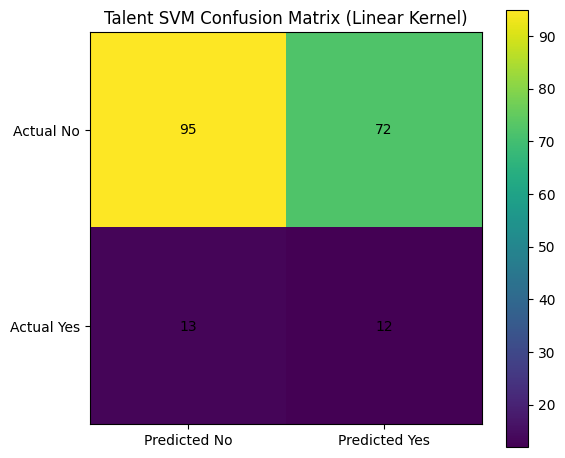

In [21]:
selected_kernel = svm_comparison.sort_values(["F1", "Recall"], ascending=False).iloc[0]["Kernel"]
selected_svm = models[selected_kernel]
selected_pred = selected_svm.predict(X_talent_test)
talent_cm = confusion_matrix(y_talent_test, selected_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(talent_cm)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(talent_cm[i, j]), ha="center", va="center")
ax.set_xticks([0, 1], labels=["Predicted No", "Predicted Yes"])
ax.set_yticks([0, 1], labels=["Actual No", "Actual Yes"])
ax.set_title(f"Talent SVM Confusion Matrix ({selected_kernel.title()} Kernel)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "talent_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

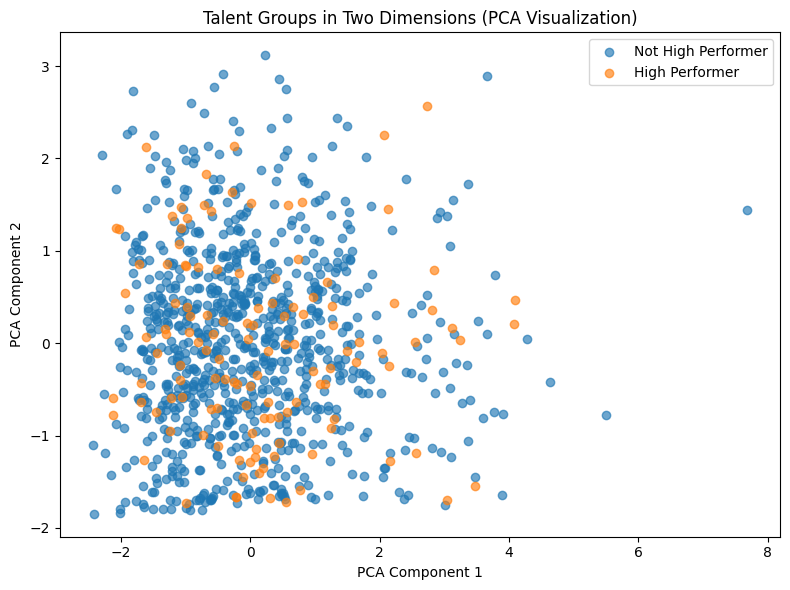

In [22]:
# PCA is only for a simple 2D visualization of the talent groups.
pca_preprocessor = make_preprocessor(
    ["Age", "Years_At_Company", "Monthly_Income"],
    ["Department", "Job_Role"]
)
talent_matrix = pca_preprocessor.fit_transform(X_talent)
talent_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(talent_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
for label, name in [(0, "Not High Performer"), (1, "High Performer")]:
    mask = y_talent.to_numpy() == label
    ax.scatter(talent_2d[mask, 0], talent_2d[mask, 1], alpha=0.65, label=name)
ax.set_title("Talent Groups in Two Dimensions (PCA Visualization)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "talent_pca_visualization.png", dpi=160, bbox_inches="tight")
plt.show()

selected_svm.fit(X_talent, y_talent)
clean["Predicted_High_Performer"] = np.where(
    selected_svm.predict(X_talent) == 1, "Yes", "No"
)

## 8. Employee Segmentation — K-Means

K-Means is an **unsupervised** model. We do **not** use Attrition or Attrition Risk when creating clusters.

To keep the segments easy to explain to HR, we cluster using four profile variables:

- Age
- Years at Company
- Monthly Income
- Performance Score

We test `k=2` through `k=6`, compare inertia and silhouette scores, then select the best-supported value.

In [23]:
cluster_features = ["Age", "Years_At_Company", "Monthly_Income", "Performance_Score"]
cluster_scaler = StandardScaler()
cluster_input = cluster_scaler.fit_transform(clean[cluster_features])

cluster_tests = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(cluster_input)
    cluster_tests.append({
        "k": k,
        "Inertia": km.inertia_,
        "Silhouette_Score": silhouette_score(cluster_input, labels)
    })

cluster_tests = pd.DataFrame(cluster_tests)
display(cluster_tests)

,k,Inertia,Silhouette_Score
0,2,2858.214438,0.281406
1,3,2336.856188,0.216143
2,4,1963.840639,0.217156
3,5,1759.095116,0.217676
4,6,1612.999852,0.209932


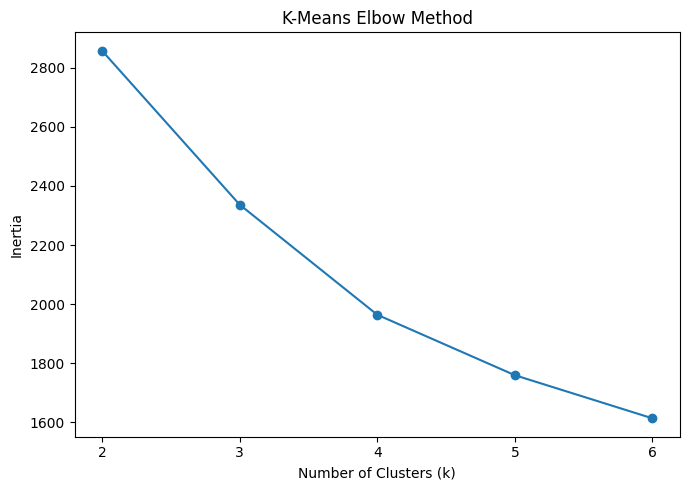

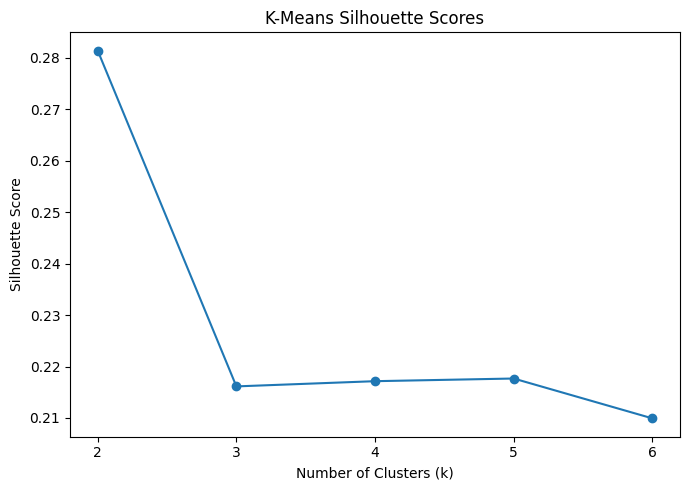

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cluster_tests["k"], cluster_tests["Inertia"], marker="o")
ax.set_title("K-Means Elbow Method")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_xticks(cluster_tests["k"])
plt.tight_layout()
plt.savefig(FIGURES / "kmeans_elbow.png", dpi=160, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(cluster_tests["k"], cluster_tests["Silhouette_Score"], marker="o")
ax.set_title("K-Means Silhouette Scores")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(cluster_tests["k"])
plt.tight_layout()
plt.savefig(FIGURES / "kmeans_silhouette.png", dpi=160, bbox_inches="tight")
plt.show()

`k=2` has the strongest silhouette score in this dataset, so two clusters are the simplest well-supported segmentation.

In [25]:
selected_k = int(cluster_tests.loc[cluster_tests["Silhouette_Score"].idxmax(), "k"])
final_kmeans = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=20)
clean["Cluster"] = final_kmeans.fit_predict(cluster_input)

cluster_profiles = clean.groupby("Cluster")[cluster_features].mean().round(2)
cluster_profiles["Employee_Count"] = clean.groupby("Cluster").size()
display(cluster_profiles)

,Age,Years_At_Company,Monthly_Income,Performance_Score,Employee_Count
Cluster,,,,,
0,34.14,1.57,4302.59,71.37,698
1,34.25,7.29,6375.75,72.37,262


The cluster profiles show two clear, HR-friendly groups:

- **Short-Tenure, Lower-Income Employees** — newer employees with lower average income. Retention should emphasize onboarding, manager check-ins and visible career/pay progression.
- **Established, Higher-Income Employees** — longer-tenure employees with higher average income. Retention should emphasize career growth, recognition, succession paths and retention conversations.

Performance scores are fairly similar between the two groups, so the biggest separation is tenure and income rather than performance.

In [26]:
overall = clean[cluster_features].mean()
segment_names = {}
retention_actions = {}

for cluster_id, row in cluster_profiles.iterrows():
    if row["Years_At_Company"] <= overall["Years_At_Company"] * 0.75:
        tenure_label = "Short-Tenure"
        retention = "Strengthen onboarding, manager check-ins, and visible career/pay progression."
    elif row["Years_At_Company"] >= overall["Years_At_Company"] * 1.25:
        tenure_label = "Established"
        retention = "Focus on career growth, recognition, succession paths, and retention conversations."
    else:
        tenure_label = "Mid-Tenure"
        retention = "Provide development opportunities, recognition, and regular career conversations."

    if row["Monthly_Income"] <= overall["Monthly_Income"] * 0.90:
        income_label = "Lower-Income"
    elif row["Monthly_Income"] >= overall["Monthly_Income"] * 1.10:
        income_label = "Higher-Income"
    else:
        income_label = "Mid-Income"

    segment_names[int(cluster_id)] = f"{tenure_label}, {income_label} Employees"
    retention_actions[int(cluster_id)] = retention

clean["Employee_Segment"] = clean["Cluster"].map(segment_names)
print(clean["Employee_Segment"].value_counts())

Employee_Segment
Short-Tenure, Lower-Income Employees    698
Established, Higher-Income Employees    262
Name: count, dtype: int64


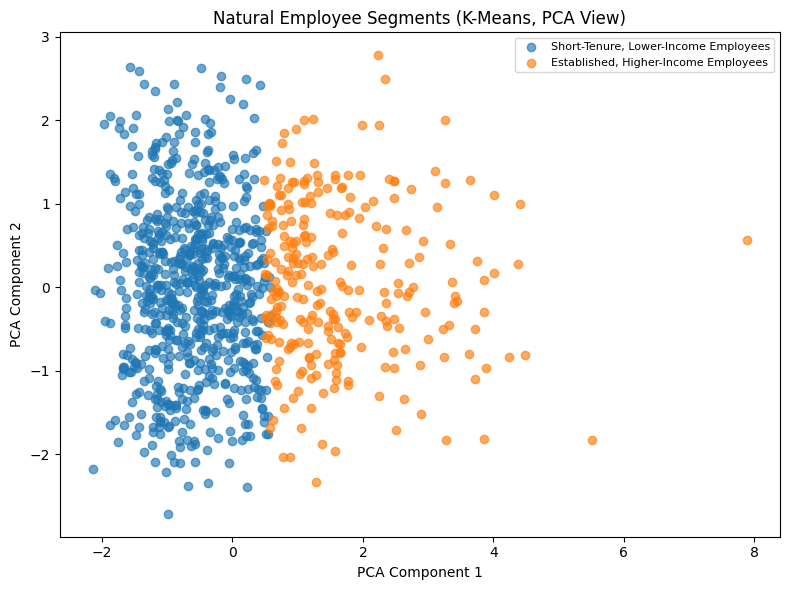

In [27]:
segment_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(cluster_input)
fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id in sorted(clean["Cluster"].unique()):
    mask = clean["Cluster"].to_numpy() == cluster_id
    ax.scatter(
        segment_2d[mask, 0], segment_2d[mask, 1],
        alpha=0.65, label=segment_names[int(cluster_id)]
    )
ax.set_title("Natural Employee Segments (K-Means, PCA View)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "employee_segments_pca.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Export Final Dataset for Power BI

The final reporting CSV keeps the original human-readable employee fields and adds the analysis results. We do **not** export scaled values in place of the original values.

In [28]:
export_df = clean.copy()
export_df["Join_Date"] = export_df["Join_Date"].dt.strftime("%Y-%m-%d")
export_df["Age"] = export_df["Age"].round(0).astype(int)
export_df["Years_At_Company"] = export_df["Years_At_Company"].round(1)
export_df["Monthly_Income"] = export_df["Monthly_Income"].round(2)
export_df["Performance_Score"] = export_df["Performance_Score"].round(1)
export_df["Predicted_Income"] = export_df["Predicted_Income"].round(2)
export_df["Pay_Gap"] = export_df["Pay_Gap"].round(2)
export_df["Pay_Gap_Percent"] = export_df["Pay_Gap_Percent"].round(1)
export_df["Attrition_Risk_Probability"] = export_df["Attrition_Risk_Probability"].round(4)

base_columns = [
    "Employee_ID", "Department", "Job_Role", "Education_Level", "Age",
    "Years_At_Company", "Monthly_Income", "Performance_Score",
    "Join_Date", "Attrition"
]
final_columns = base_columns + [
    "Predicted_Income", "Pay_Gap", "Pay_Gap_Percent", "Pay_Equity_Flag",
    "Attrition_Risk_Probability", "Attrition_Risk_Level",
    "High_Performer", "Predicted_High_Performer",
    "Cluster", "Employee_Segment"
]

export_df[base_columns].to_csv(ROOT / "employee_attrition_cleaned.csv", index=False)
export_df[final_columns].to_csv(ROOT / "employee_attrition_final.csv", index=False)

pay_flags[[
    "Employee_ID", "Department", "Job_Role", "Monthly_Income",
    "Predicted_Income", "Pay_Gap", "Pay_Gap_Percent", "Pay_Equity_Flag"
]].sort_values("Pay_Gap").to_csv(ROOT / "pay_equity_flags.csv", index=False)

svm_comparison.to_csv(ROOT / "svm_model_comparison.csv", index=False)
cluster_tests.to_csv(ROOT / "kmeans_k_selection.csv", index=False)

cluster_export = clean.groupby("Cluster")[cluster_features].mean().round(2).reset_index()
cluster_export["Employee_Count"] = clean.groupby("Cluster").size().values
cluster_export["Employee_Segment"] = cluster_export["Cluster"].map(segment_names)
cluster_export["Suggested_Retention_Action"] = cluster_export["Cluster"].map(retention_actions)
cluster_export.to_csv(ROOT / "cluster_profiles.csv", index=False)

print("Final CSV shape:", export_df[final_columns].shape)
display(export_df[final_columns].head())

Final CSV shape: (960, 20)


,Employee_ID,Department,Job_Role,Education_Level,Age,Years_At_Company,Monthly_Income,Performance_Score,Join_Date,Attrition,Predicted_Income,Pay_Gap,Pay_Gap_Percent,Pay_Equity_Flag,Attrition_Risk_Probability,Attrition_Risk_Level,High_Performer,Predicted_High_Performer,Cluster,Employee_Segment
0,601,Engineering,Software Engineer,Bachelor,21,13.0,7155.17,92.0,2011-07-15,No,7219.13,-63.96,-0.9,Within Expected Range,0.1192,Low,1,No,1,"Established, Higher-Income Employees"
1,737,Sales,Sales Executive,Master,30,2.0,5122.52,59.0,2022-09-22,No,5304.98,-182.46,-3.4,Within Expected Range,0.6413,Medium,0,Yes,0,"Short-Tenure, Lower-Income Employees"
2,315,Finance,Accountant,Bachelor,37,0.0,4578.13,80.0,2024-06-18,No,3772.18,805.95,21.4,Within Expected Range,0.6481,Medium,0,No,0,"Short-Tenure, Lower-Income Employees"
3,816,Sales,Sales Manager,Bachelor,31,0.0,3649.32,79.0,2024-08-15,No,3798.31,-148.99,-3.9,Within Expected Range,0.5154,Medium,0,No,0,"Short-Tenure, Lower-Income Employees"
4,979,Marketing,Marketing Analyst,Bachelor,42,2.0,4218.21,75.0,2022-09-07,No,4430.12,-211.91,-4.8,Within Expected Range,0.5862,Medium,0,No,0,"Short-Tenure, Lower-Income Employees"


## 10. Key HR Findings

- The raw file had **1,045 rows**. Text standardization revealed **45 duplicate employee rows**, leaving 1,000 unique employees before outlier removal.
- Hidden missing-value placeholders included `?` and `-999`. KNN imputation removed all required numeric missing values.
- LOF flagged and removed **40** unusual records. The final analysis dataset contains **960 employees**.
- Final observed attrition rate: **16.0%**.
- Pay-equity Linear Regression: **R² = 0.636**, MAE = **632**. There are **20 Below Expected** and **19 Above Expected** review flags.
- Attrition Logistic Regression has **ROC-AUC = 0.571** and recall **0.581**, so its predictive power is limited and should not be overclaimed.
- The **Linear SVM** performed better than the other SVM setting by F1, but the talent prediction remains weak.
- K-Means selected **k = 2**, producing a short-tenure/lower-income group and an established/higher-income group.

## 11. Final Conclusion

This project completes the required preprocessing and all four analytical tasks. The strongest model is the pay-equity regression, while the attrition and talent classifiers have limited predictive strength. This is an important finding: a responsible analysis reports weak model performance instead of pretending that every model is highly accurate.

The final CSV is ready for the required Power BI dashboard. See the `powerbi/` folder for the DAX measures, dashboard layout, mockup and exact build instructions.